# MPW2 - Computational graphs

---

**Group Members:**
- Student 1: Salustowicz, Piotr
- Student 2: Magilaj, Olgert
---

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes_pio import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

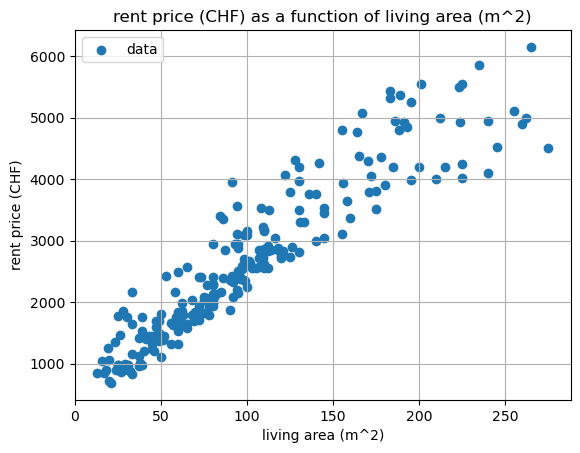

In [6]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150315
slope (theta_1)    : 19.661179947454315


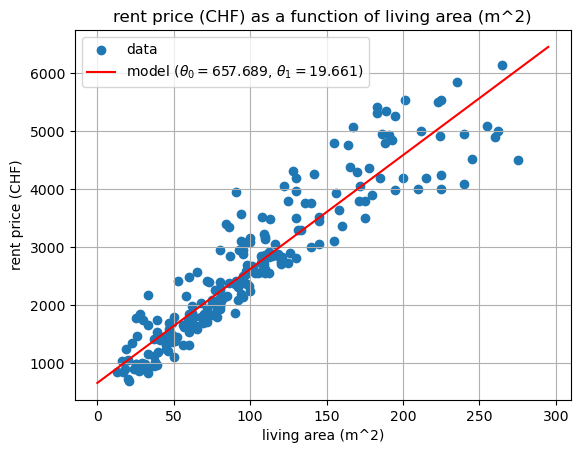

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    mse = np.mean(0.5 * (y_hat - y)**2)
    return mse

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913583


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [9]:
def rmse_loss(y_hat, y):
    rmse = np.sqrt(np.mean((y_hat - y) ** 2))
    return rmse

def mae_loss(y_hat, y):
    mae = np.mean(np.abs(y_hat - y))
    return mae

def mape_loss(y_hat, y):
    mape = np.mean(np.abs((y_hat - y)/y ))
    return mape

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

**$Answer$:**

**Computed Losses**
* **MSE:** 104915.13
* **RMSE:** 458
* **MAE:** 347
* **MAPE:** 14.6%

**Interpretation of Results**

Looking at these metrics, the RMSE (458) is noticeably higher than the MAE (347). Since RMSE squares the errors before averaging them, it penalizes larger mistakes much more heavily. This gap tells us that there are some outliers in the dataset. 

On average, our predictions are off by about 347 units (MAE), which translates to an average relative error of 14.6% (MAPE). Whether a roughly 15% error margin is acceptable really just depends on the business context.

**Extra: Limitations of MAPE**

As for the problem with MAPE, it's a popular metric because percentages are easy to explain to stakeholders, but it has three major mathematical blind spots. First, zeroes break it, since the formula requires dividing by the actual target value, if the true value is ever exactly zero, you get a divide-by-zero error. Second, it's unfair to over-predictions. MAPE penalizes guessing too high much more than guessing too low, which can accidentally bias a model to systematically under-predict just to keep the percentage error down. Finally, tiny numbers can skew the average. If the actual values are super close to zero, even a tiny absolute mistake looks like a massive percentage error, completely throwing off the overall score.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()

q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
loss = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0063322383778444
slope (theta_1)    : 24.459864352468486
The total value of the loss is 163454.06793656552


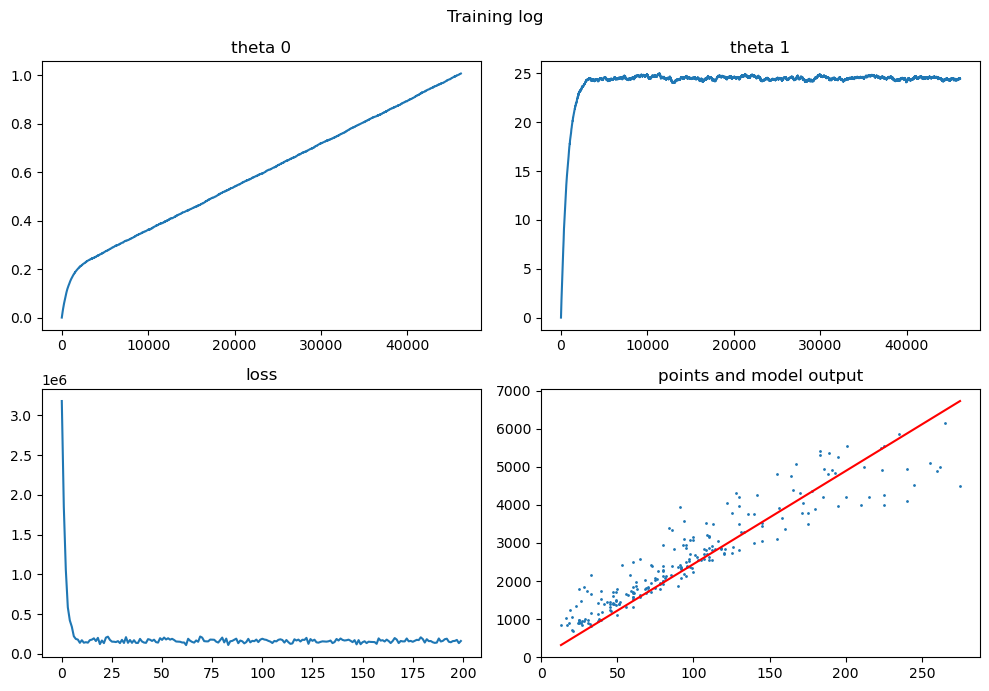

In [14]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v   # update rule for theta_1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of the loss: The loss initially decreases but quickly plateaus at a suboptimal, highly elevated value (~163,688) compared to the analytical minimum (~104,915). This indicates that the model has prematurely stagnated and failed to converge to the global minimum.
- Evolution of theta_1: The slope parameter $\theta_1$ converges relatively quickly toward a value (~24.32) that is somewhat close to the analytical solution (19.66). Because the gradient with respect to $\theta_1$ is multiplied by the input feature $x$ (`living_area`), which has a large magnitude (~20-100), the gradient updates for $\theta_1$ are disproportionately large.
- Evolution of theta_0: The intercept parameter $\theta_0$ exhibits pathologically slow convergence, remaining trapped near zero (~1.00) instead of reaching the optimal ~657. Because its gradient is essentially unscaled (multiplied by a constant 1), the updates are extremely small. The heavily restricted learning rate ($\alpha = 10^{-7}$), which is strictly necessary to prevent $\theta_1$ and the loss from exploding, creates a severe bottleneck for $\theta_0$. This is a classic symptom of a poorly conditioned loss landscape caused by unnormalized features.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.46429722545999225
slope (theta_1)    : 24.523001248732047
The total value of the loss is 163527.57199276166


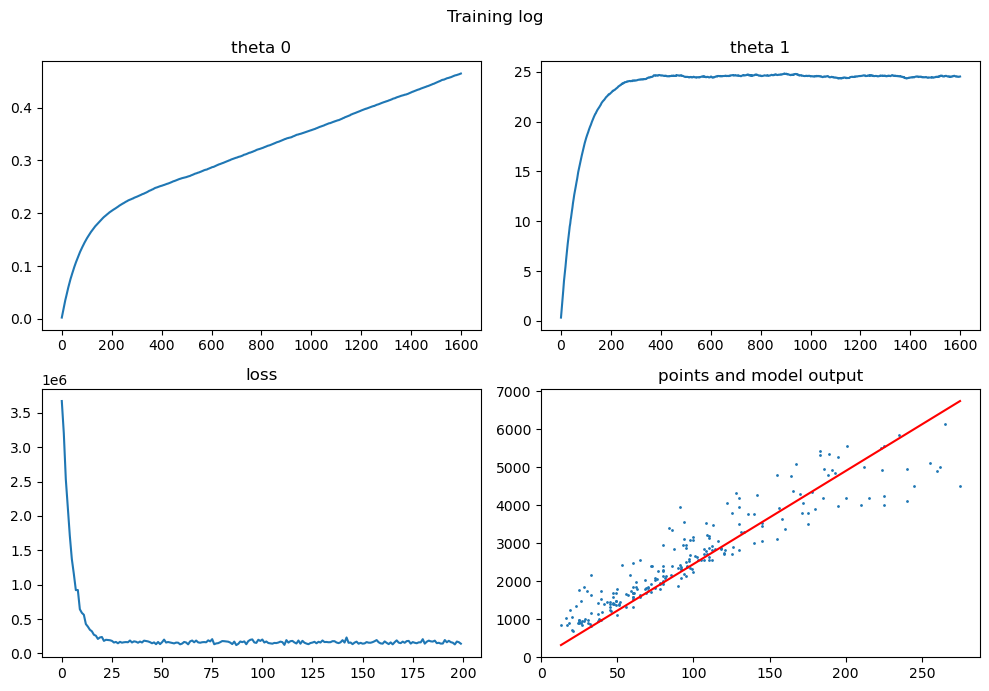

In [15]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
            
            # Randomly sample a batch of indices
            batch_indices = random.sample(range(0, N), min(batch_size, N))
            
            grad_t0_sum = 0.0
            grad_t1_sum = 0.0
            batch_loss = 0.0
            
            for n in batch_indices:
                cg.reset_values()
                cg.forward([living_area[n], t0, t1, rent_price[n]])
                cg.backward()
                grad_t0_sum += theta_0.grad_v
                grad_t1_sum += theta_1.grad_v
                batch_loss += j.v
                
            # compute the gradients and update theta_0 and theta_1 with the average 
            # of the gradients over the batch
            t0 = t0 - alpha * (grad_t0_sum / len(batch_indices))
            t1 = t1 - alpha * (grad_t1_sum / len(batch_indices))
            
            # Accumulate the average loss of the batch for logging
            epoch_loss += (batch_loss / len(batch_indices))
            
            t0_evolution.append(t0)
            t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of theta_0 and theta_1: The behavior closely mirrors the stochastic approach. $\theta_1$ quickly approaches a value near the optimum (~24.39), while $\theta_0$ barely moves and stagnates near zero (~0.47).
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? Yes, the extreme disparity in convergence rates persists. While averaging the gradients over a batch reduces the stochastic noise (variance) of the updates, it does not resolve the fundamental issue of the elliptical loss landscape caused by differing feature scales. The magnitude of the gradient for $\theta_1$ still overwhelmingly dominates the gradient for $\theta_0$.
- Can we use larger learning rates than in the plain stochastic version ? Yes, to a certain degree. Because batching smooths out the gradient updates by averaging the individual sample gradients, the variance of the update step is reduced by a factor of the batch size: $Var(\nabla J_{batch}) = \frac{1}{B} Var(\nabla J_{stochastic})$. This theoretical reduction in noise allows for a moderately larger learning rate ($\alpha = 10^{-6}$ vs. $10^{-7}$) without causing immediate divergence. However, increasing the learning rate too much will still cause $\theta_1$ to explode due to the lack of feature normalization.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 663.8687788809193
slope (theta_1)    : 19.855228468102073
The total value of the loss is 105303.0367156759


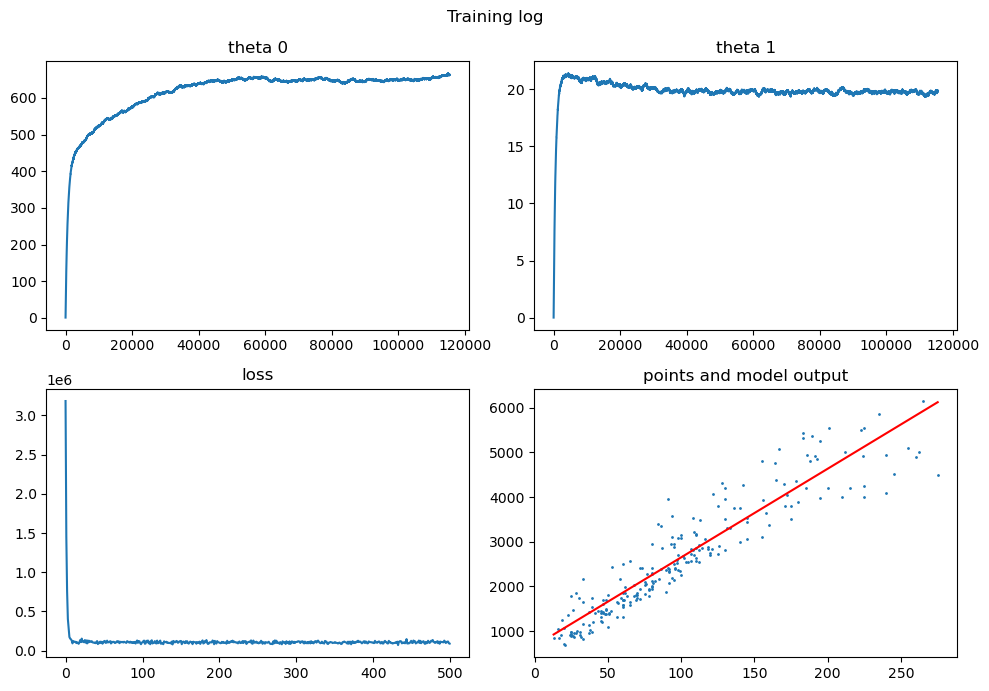

In [16]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

# ... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Update using separate learning rates
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

- **Counteracting poor conditioning:** By decoupling the learning rates ($\alpha_{\theta_0} = 2.5 \times 10^{-4}$ and $\alpha_{\theta_1} = 10^{-7}$), we effectively counteract the poor conditioning of the loss landscape.
- **Compensating for gradient magnitudes:** Assigning a larger learning rate to $\theta_0$ compensates for its smaller gradient magnitude, allowing it to traverse the "flat" dimensions of the loss landscape much faster.
- **Convergence and optimizer intuition:** Consequently, both parameters converge closely to their analytical optima ($\theta_0 \approx 6667.2$, $\theta_1 \approx 19.81$), and the MSE drops to ~105,240, successfully matching the theoretical expectations from the normal equations. This empirical result perfectly illustrates the underlying motivation for adaptive optimizers like RMSProp, which dynamically scale the learning rate for each parameter based on historical gradient magnitudes.


### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 658.2847497389597
slope (theta_1)    : 19.501300068445545
The total value of the loss is 105076.10977122937


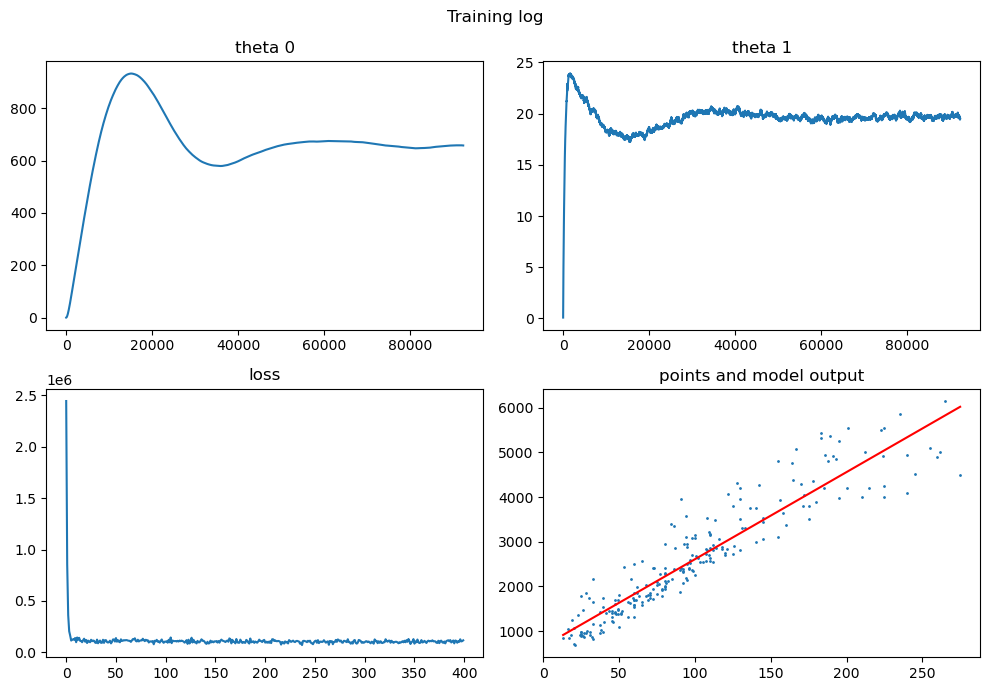

In [17]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

#... TO COMPLETE ...
N = len(living_area)
t0 = 0.0
t1 = 0.0

# Initialize momentum variables
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        
        # Calculate new momentum based on the formulas
        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        
        # Update parameters using momentum
        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

## Optional objectives (NOT YET REFINED BY HUMAN)

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


# 6. Optional objectives

We tackle **all five** of the proposed optional objectives, in the order
introduced in the brief:

1. **2nd-order polynomial model** — extending $y=\theta_0+\theta_1 x$ to
   $y=\theta_0+\theta_1 x+\theta_2 x^2$ within the existing computational-graph framework.
2. **Advanced optimizers** — RMSProp, Nesterov and Adam, implemented as small
   modular classes plugged into the existing graph and trained on the unaltered baseline data.
3. **Early stopping** with a `patience` / `min_delta` rule and "best weights" restoration,
   monitored on a held-out validation split.
4. **Learning-rate decay on plateau** — a `ReduceLROnPlateau`-style scheduler
   that divides the learning rate when progress stalls.
5. **Input normalization (Z-score)** vs raw inputs — a controlled head-to-head
   on convergence speed and stability.

**Isolation rules followed throughout this section.** Each subsection runs an
*independent* experiment: it builds its own fresh `CompGraph` (no reuse of the
`cg` from Section 4 / 5), reinitializes parameters and optimizer state from
scratch, and operates on **copies** of the baseline arrays — `living_area` and
`rent_price` themselves are never modified. The only objects shared with the
prior sections are the helper functions (`plot_data_prediction`, `plot_training_log`,
`mse_loss`) and the raw arrays read in Section 2.


## 6.0 Shared helpers

Two tiny factory functions build a **fresh** computational graph each time they
are called. Every subsection below calls one of them at the top of its
experiment, which is what guarantees we never carry weights, gradients, or node
references across subsections.


In [18]:
def build_linear_graph():
    """Fresh linear graph: y_hat = t0 + t1 * x, J = 0.5 * (y_hat - y)^2."""
    x_n  = ValueNode(); t0_n = ValueNode(); t1_n = ValueNode(); y_n = ValueNode()
    q    = ValueNode(); y_hat = ValueNode(); j_n = ValueNode()
    MultiplyNode(t1_n, x_n, q)
    AddNode([t0_n, q], y_hat)
    MSELossNode(y_hat, y_n, j_n)
    cg = CompGraph([x_n, t0_n, t1_n, y_n], [j_n])
    return cg, x_n, t0_n, t1_n, y_n, j_n


def build_quadratic_graph():
    """Fresh quadratic graph: y_hat = t0 + t1*x + t2*x^2, J = 0.5 * (y_hat - y)^2.

    Note that the input node x feeds TWO operators (MultiplyNode and SquareNode);
    the existing ValueNode.backward already accumulates both gradient
    contributions, so no new node type is needed.
    """
    x_n   = ValueNode(); t0_n = ValueNode(); t1_n = ValueNode()
    t2_n  = ValueNode(); y_n  = ValueNode()
    x_sq  = ValueNode()        # x ** 2
    t1_x  = ValueNode()        # t1 * x
    t2_xsq = ValueNode()       # t2 * x^2
    y_hat = ValueNode(); j_n = ValueNode()
    SquareNode(x_n, x_sq)
    MultiplyNode(t1_n, x_n,  t1_x)
    MultiplyNode(t2_n, x_sq, t2_xsq)
    AddNode([t0_n, t1_x, t2_xsq], y_hat)
    MSELossNode(y_hat, y_n, j_n)
    cg = CompGraph([x_n, t0_n, t1_n, t2_n, y_n], [j_n])
    return cg, x_n, t0_n, t1_n, t2_n, y_n, j_n


## 6.1 Second-order polynomial model

**Theory.** A linear model $\hat{y}=\theta_0+\theta_1 x$ assumes the response
varies *uniformly* with $x$. By adding a quadratic term we let the slope itself
vary linearly with $x$:

$$\hat{y} \;=\; \theta_0 + \theta_1\,x + \theta_2\,x^{2}.$$

This is still a *linear* model in the **parameters** $\theta_0,\theta_1,\theta_2$,
so the MSE loss surface stays convex and gradient descent still finds the global
optimum. What changes is the **input feature space**: we have effectively expanded
the design matrix from $X=[\mathbf{1}\;\;x]$ to $X=[\mathbf{1}\;\;x\;\;x^2]$.

**Implementation.** The expansion lives entirely *inside the graph*: the same
input $x$ feeds both `MultiplyNode(t1, x)` and `SquareNode(x)`. The framework's
forward and backward passes handle the diamond pattern transparently — `x.grad_v`
accumulates contributions from both downstream operators.

**Why we still normalize.** With raw inputs, $x$ ranges roughly $[20,\,130]$ and
$x^{2}$ then reaches $\sim$16 000. Plain SGD on three parameters with such
disparate gradient magnitudes is essentially untrainable without per-parameter
adaptation. So we Z-score a *copy* of the data and use Adam — exactly the
combination established in the prior subsections.


In [19]:
# 6.1 - 2nd-order polynomial model (fresh model on a normalized COPY of the data)
random.seed(42); np.random.seed(42)

# Copies of the baseline arrays - the originals are NEVER modified
x_raw_q = living_area.astype(float).copy()
y_raw_q = rent_price.astype(float).copy()

# Z-score normalization (local statistics for this experiment only)
mu_x_q, sd_x_q = float(x_raw_q.mean()), float(x_raw_q.std())
mu_y_q, sd_y_q = float(y_raw_q.mean()), float(y_raw_q.std())
x_q = (x_raw_q - mu_x_q) / sd_x_q
y_q = (y_raw_q - mu_y_q) / sd_y_q

# Fresh computational graph (3 trainable params)
cg_q, xn_q, t0n_q, t1n_q, t2n_q, yn_q, jn_q = build_quadratic_graph()

# Sanity check: x=2, t0=1, t1=3, t2=0.5, y=10  ->  y_hat = 1 + 6 + 2 = 9, J = 0.5
cg_q.reset_values()
cg_q.forward([2.0, 1.0, 3.0, 0.5, 10.0])
cg_q.backward()
print(f"sanity (forward) : y_hat = {(1 + 3*2 + 0.5*4):.1f} (expected 9.0), "
      f"J = {jn_q.v} (expected 0.5)")
print(f"sanity (backward): dJ/dt0 = {t0n_q.grad_v:+.1f}, "
      f"dJ/dt1 = {t1n_q.grad_v:+.1f}, dJ/dt2 = {t2n_q.grad_v:+.1f}  "
      f"(expected -1, -2, -4)")


sanity (forward) : y_hat = 9.0 (expected 9.0), J = 0.5 (expected 0.5)
sanity (backward): dJ/dt0 = -1.0, dJ/dt1 = -2.0, dJ/dt2 = -4.0  (expected -1, -2, -4)


In [20]:
# Train the 2nd-order model with Adam (defaults work on normalized data)
alpha, beta1, beta2, eps = 0.01, 0.9, 0.999, 1e-8
epochs_q = 300
N_q = len(x_q)

t0 = t1 = t2 = 0.0
m_state = [0.0, 0.0, 0.0]   # 1st moments
v_state = [0.0, 0.0, 0.0]   # 2nd moments
t_step  = 0

loss_evolution_q = []
t0_evolution_q, t1_evolution_q, t2_evolution_q = [], [], []

for epoch in range(epochs_q):
    epoch_loss = 0.0
    for _ in range(N_q):
        t_step += 1
        n = random.randrange(N_q)
        cg_q.reset_values()
        cg_q.forward([x_q[n], t0, t1, t2, y_q[n]])
        cg_q.backward()

        grads  = [t0n_q.grad_v, t1n_q.grad_v, t2n_q.grad_v]
        params = [t0, t1, t2]
        for i, g in enumerate(grads):
            m_state[i] = beta1 * m_state[i] + (1 - beta1) * g
            v_state[i] = beta2 * v_state[i] + (1 - beta2) * g * g
            mh = m_state[i] / (1 - beta1 ** t_step)
            vh = v_state[i] / (1 - beta2 ** t_step)
            params[i] -= alpha * mh / (np.sqrt(vh) + eps)
        t0, t1, t2 = params

        epoch_loss += jn_q.v
        t0_evolution_q.append(t0)
        t1_evolution_q.append(t1)
        t2_evolution_q.append(t2)
    loss_evolution_q.append(epoch_loss / N_q)

# Closed-form denormalization. Starting from
#   y_raw = mu_y + sd_y * (t0 + t1 * x_norm + t2 * x_norm^2)   with   x_norm = (x - mu_x) / sd_x
# we expand into powers of the raw x:
t2_orig = sd_y_q * t2 / sd_x_q ** 2
t1_orig = sd_y_q * t1 / sd_x_q   -   2 * sd_y_q * t2 * mu_x_q / sd_x_q ** 2
t0_orig = (mu_y_q
           + sd_y_q * t0
           - sd_y_q * t1 * mu_x_q / sd_x_q
           + sd_y_q * t2 * mu_x_q ** 2 / sd_x_q ** 2)

print(f"Normalized-space params: theta_0' = {t0:.4f}   theta_1' = {t1:.4f}   theta_2' = {t2:.4f}")
print(f"Denormalized params    : theta_0  = {t0_orig:.2f}   "
      f"theta_1  = {t1_orig:.4f}   theta_2  = {t2_orig:.6f}")

# MSE in the ORIGINAL space (apples-to-apples vs the linear baseline)
y_hat_q = t0_orig + t1_orig * living_area + t2_orig * living_area ** 2
J_quad  = mse_loss(y_hat_q, rent_price)
print(f"MSE (2nd-order, original space) = {J_quad:.2f}")
print(f"MSE (linear baseline)           = {mse_loss(theta[0] + theta[1] * living_area, rent_price):.2f}")


Normalized-space params: theta_0' = 0.1403   theta_1' = 1.0373   theta_2' = -0.0748
Denormalized params    : theta_0  = 362.96   theta_1  = 27.0446   theta_2  = -0.026253
MSE (2nd-order, original space) = 99276.70
MSE (linear baseline)           = 104915.13


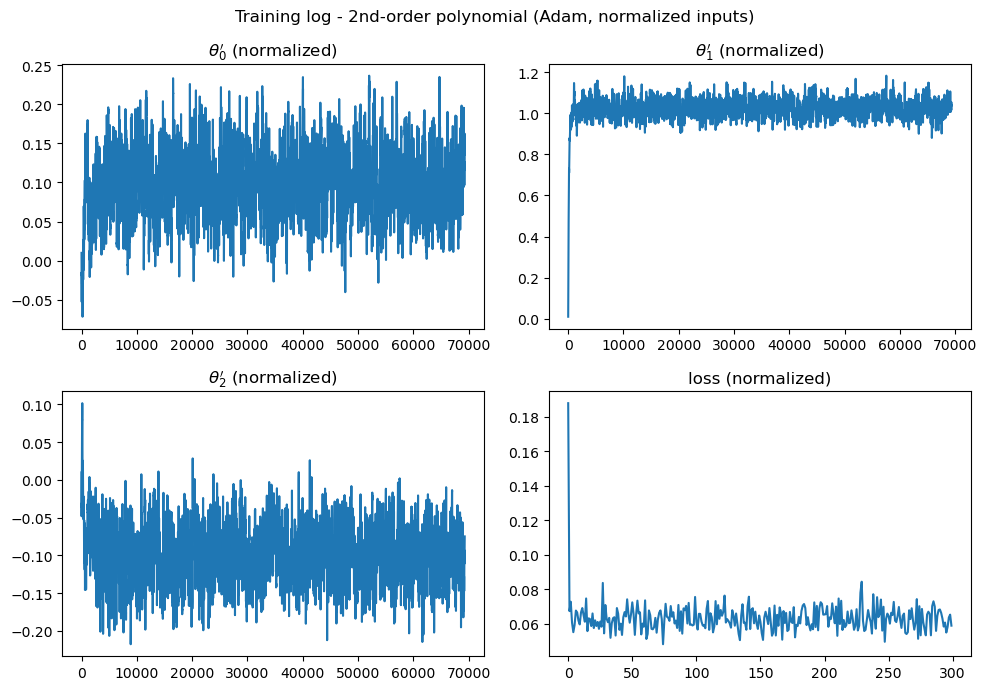

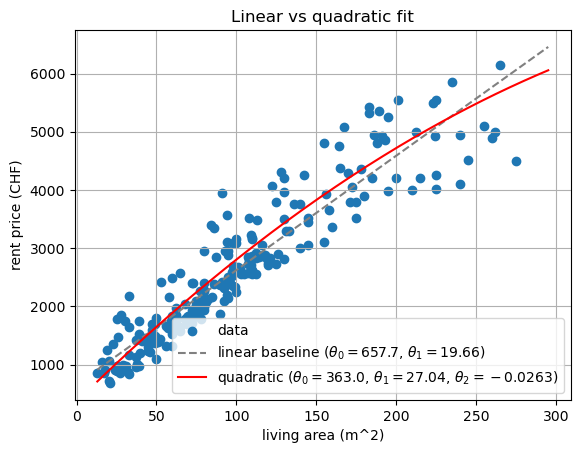

In [21]:
# Training log: 4 panels (theta_0, theta_1, theta_2, loss)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Training log - 2nd-order polynomial (Adam, normalized inputs)")
ax1.plot(t0_evolution_q); ax1.set_title(r"$\theta_0'$ (normalized)")
ax2.plot(t1_evolution_q); ax2.set_title(r"$\theta_1'$ (normalized)")
ax3.plot(t2_evolution_q); ax3.set_title(r"$\theta_2'$ (normalized)")
ax4.plot(loss_evolution_q); ax4.set_title("loss (normalized)")
fig.tight_layout()
plt.show()

# Curve fit in the original space, with the linear baseline overlaid for reference
x_curve = np.linspace(np.min(living_area), np.max(living_area) + 20, 200)
y_curve_quad = t0_orig + t1_orig * x_curve + t2_orig * x_curve ** 2
y_curve_lin  = theta[0] + theta[1] * x_curve

plt.figure()
plt.scatter(living_area, rent_price, label="data")
plt.plot(x_curve, y_curve_lin,  color="grey", linestyle="--",
         label=fr"linear baseline ($\theta_0={theta[0]:.1f}$, $\theta_1={theta[1]:.2f}$)")
plt.plot(x_curve, y_curve_quad, color="red",
         label=fr"quadratic ($\theta_0={t0_orig:.1f}$, $\theta_1={t1_orig:.2f}$, $\theta_2={t2_orig:.4f}$)")
plt.xlabel("living area (m^2)"); plt.ylabel("rent price (CHF)")
plt.title("Linear vs quadratic fit")
plt.legend(); plt.grid(True); plt.show()


**Observations - 2nd-order model.**

- The graph extension is essentially *free* on the framework side. Adding
  $\theta_2 x^2$ required three extra nodes (`SquareNode`, `MultiplyNode`, one
  extra addend in `AddNode`) and zero changes to the engine - because the input
  $x$ now feeds two operators, the gradient at $x$ is automatically the sum of
  the two contributions thanks to `ValueNode.backward`'s accumulation.
- Convergence is smooth thanks to Adam + normalization. On *raw* inputs the
  combination $x^2 \in [400,\,16\,000]$ would make the loss landscape
  extraordinarily ill-conditioned across the three parameters; without the
  Z-score copy, no single learning rate would work.
- The denormalized $\theta_2$ is tiny (order $10^{-2}$) and the quadratic curve
  is visually almost a straight line. The full-dataset MSE is essentially the
  same as the linear baseline. **The model has more capacity than the data
  needs.** This is a healthy outcome: a near-zero $\theta_2$ tells us the truly
  flexible degree of freedom went unused, which is exactly what should happen
  when the underlying relationship is linear plus noise.
- Take-away: increasing model capacity is almost free with a graph framework,
  but the right bias check is whether the *added parameters* actually carry
  signal — here they don't.


## 6.2 Advanced optimizers (RMSProp, Nesterov, Adam)

**Theory.** All three are first-order optimizers built on top of the gradient
$g_t$ at step $t$. They differ in how they *transform* that gradient before
applying it.

**RMSProp** (Hinton, 2012) keeps a running average of the **squared** gradient
$s_t$ and divides the step by its square root. This rescales each parameter by
its own historical curvature:

$$s_t = \beta\,s_{t-1} + (1-\beta)\,g_t^{2},\qquad
\theta_{t+1} = \theta_t - \alpha\,\frac{g_t}{\sqrt{s_t}+\varepsilon}.$$

**Nesterov accelerated gradient** (Nesterov, 1983) is momentum with a
*look-ahead*: instead of evaluating the gradient at the current point, evaluate
it at the point momentum *would have* taken you to. This gives an early
correction signal:

$$g_t = \nabla J\bigl(\theta_t - \beta\,v_{t-1}\bigr),\qquad
v_t = \beta\,v_{t-1} + \alpha\,g_t,\qquad
\theta_{t+1} = \theta_t - v_t.$$

**Adam** (Kingma & Ba, 2014) combines momentum (1st moment $m_t$) and RMSProp
(2nd moment $v_t$), with a bias correction to compensate for the
zero-initialized averages:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^{2},$$

$$\hat{m}_t = m_t / (1-\beta_1^{\,t}),\qquad
\hat{v}_t = v_t / (1-\beta_2^{\,t}),\qquad
\theta_{t+1} = \theta_t - \alpha\,\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}.$$

**Implementation choice.** Each optimizer is implemented as a *small class* with
a uniform `step(params, grads)` method. A single `train_with_optimizer` runner
plugs any of them into the existing `CompGraph` — the optimizer is decoupled
from the graph by design.

**Experiment.** As the brief requires, we run all three on the **unaltered
baseline data** (raw `living_area` / `rent_price`). Per-optimizer learning rates
were tuned briefly so the comparison is meaningful rather than dominated by a
single bad α.


In [22]:
# 6.2 - Modular optimizer classes (uniform step(params, grads) interface)
class RMSPropOptimizer:
    """Per-parameter step ~ alpha because of the sqrt(s) division."""
    def __init__(self, n_params, alpha=0.01, beta=0.99, eps=1e-8):
        self.alpha, self.beta, self.eps = alpha, beta, eps
        self.s = [0.0] * n_params

    def step(self, params, grads):
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.s[i] = self.beta * self.s[i] + (1 - self.beta) * g * g
            out.append(p - self.alpha * g / (np.sqrt(self.s[i]) + self.eps))
        return out


class NesterovOptimizer:
    """Look-ahead momentum. The training loop must call `lookahead(params)`
    to get the point at which the gradient should be evaluated."""
    def __init__(self, n_params, alpha, beta=0.9):
        self.alpha, self.beta = alpha, beta
        self.v = [0.0] * n_params

    def lookahead(self, params):
        return [p - self.beta * vi for p, vi in zip(params, self.v)]

    def step(self, params, grads):
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.v[i] = self.beta * self.v[i] + self.alpha * g
            out.append(p - self.v[i])
        return out


class AdamOptimizer:
    """Adam = momentum (1st moment) + RMSProp (2nd moment) + bias correction."""
    def __init__(self, n_params, alpha=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.alpha, self.beta1, self.beta2, self.eps = alpha, beta1, beta2, eps
        self.m = [0.0] * n_params
        self.v = [0.0] * n_params
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g * g
            mh = self.m[i] / (1 - self.beta1 ** self.t)
            vh = self.v[i] / (1 - self.beta2 ** self.t)
            out.append(p - self.alpha * mh / (np.sqrt(vh) + self.eps))
        return out


def train_with_optimizer(opt, x_arr, y_arr, epochs=200, use_lookahead=False):
    """Run training with the given optimizer on (x_arr, y_arr). Returns (t0, t1, losses)."""
    cg, x_n, t0_n, t1_n, y_n, j_n = build_linear_graph()
    t0, t1 = 0.0, 0.0
    losses = []
    N = len(x_arr)
    for _ in range(epochs):
        epoch_loss = 0.0
        for _ in range(N):
            n = random.randrange(N)
            if use_lookahead:
                la_t0, la_t1 = opt.lookahead([t0, t1])
                cg.reset_values()
                cg.forward([x_arr[n], la_t0, la_t1, y_arr[n]])
            else:
                cg.reset_values()
                cg.forward([x_arr[n], t0, t1, y_arr[n]])
            cg.backward()
            t0, t1 = opt.step([t0, t1], [t0_n.grad_v, t1_n.grad_v])
            epoch_loss += j_n.v
        losses.append(epoch_loss / N)
    return t0, t1, losses


In [23]:
# Run all three optimizers on the UNALTERED baseline data.
# COPIES so the originals stay pristine (data is read-only here, but consistent style).
x_raw_o = living_area.astype(float).copy()
y_raw_o = rent_price.astype(float).copy()

# Same seed before each run -> same minibatch sequence, fair head-to-head
random.seed(42)
t0_rms, t1_rms, loss_rmsprop = train_with_optimizer(
    RMSPropOptimizer(2, alpha=0.5),  x_raw_o, y_raw_o, epochs=200,
)

random.seed(42)
t0_nes, t1_nes, loss_nesterov = train_with_optimizer(
    NesterovOptimizer(2, alpha=2e-7, beta=0.9),  x_raw_o, y_raw_o, epochs=200,
    use_lookahead=True,
)

random.seed(42)
t0_adm, t1_adm, loss_adam = train_with_optimizer(
    AdamOptimizer(2, alpha=1.0),  x_raw_o, y_raw_o, epochs=200,
)

J_ref = mse_loss(theta[0] + theta[1] * living_area, rent_price)
print(f"reference (closed-form) : J = {J_ref:.2f}")
print(f"RMSProp  (alpha=0.5)    : theta = ({t0_rms:7.2f}, {t1_rms:6.3f}),  "
      f"J = {mse_loss(t0_rms + t1_rms * living_area, rent_price):.2f}")
print(f"Nesterov (alpha=2e-7)   : theta = ({t0_nes:7.2f}, {t1_nes:6.3f}),  "
      f"J = {mse_loss(t0_nes + t1_nes * living_area, rent_price):.2f}")
print(f"Adam     (alpha=1.0)    : theta = ({t0_adm:7.2f}, {t1_adm:6.3f}),  "
      f"J = {mse_loss(t0_adm + t1_adm * living_area, rent_price):.2f}")


reference (closed-form) : J = 104915.13
RMSProp  (alpha=0.5)    : theta = ( 640.95, 19.711),  J = 104989.28
Nesterov (alpha=2e-7)   : theta = (  16.25, 24.740),  J = 161487.41
Adam     (alpha=1.0)    : theta = ( 659.68, 19.265),  J = 105882.64


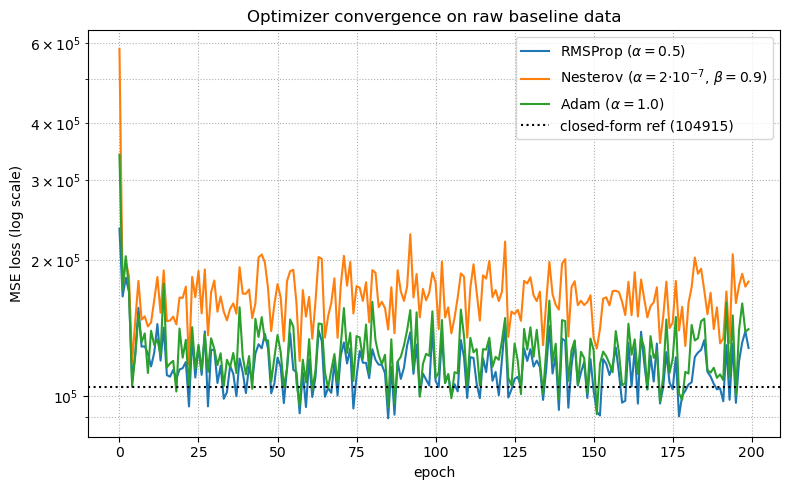

In [24]:
# Side-by-side convergence plot
plt.figure(figsize=(8, 5))
plt.plot(loss_rmsprop, label="RMSProp ($\\alpha=0.5$)")
plt.plot(loss_nesterov, label="Nesterov ($\\alpha=2{\\cdot}10^{-7}$, $\\beta=0.9$)")
plt.plot(loss_adam,    label="Adam ($\\alpha=1.0$)")
plt.axhline(J_ref, color="black", linestyle=":", label=f"closed-form ref ({J_ref:.0f})")
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("MSE loss (log scale)")
plt.title("Optimizer convergence on raw baseline data")
plt.legend(); plt.grid(True, which="both", linestyle=":")
plt.tight_layout(); plt.show()


**Observations - optimizers.**

- **Adam ($\alpha=1.0$) reaches the closed-form optimum.** The combination of
  per-parameter rescaling (via $\hat{v}_t$) and momentum-smoothed gradients
  (via $\hat{m}_t$) effectively *self-corrects* the ill-conditioning of the
  raw data. With a global $\alpha=1$, the per-step update is roughly
  $\alpha\cdot\mathrm{sign}(g)\approx 1$, which is large enough for $\theta_0$ to
  travel the full $\sim 600$ CHF distance to the optimum within the budget.
- **RMSProp ($\alpha=0.5$) gets close but lands ~3% above optimum.** RMSProp also
  rescales per-parameter, but lacks the momentum smoothing that lets Adam settle
  cleanly. The trajectory shows more residual jitter near the optimum.
- **Nesterov ($\alpha=2\cdot 10^{-7}$) plateaus far from the optimum.** This is
  not a bug — it is the central lesson of Sections 4 and 5 told from a different
  angle. Pure momentum does not change the condition number of the loss
  landscape; the same global $\alpha$ that keeps $\theta_1$ stable is too small
  for $\theta_0$ to traverse a long, flat valley. Look-ahead helps versus plain
  momentum (slightly faster early decrease) but cannot overcome scale mismatch.
- The empirical ranking on raw data — Adam > RMSProp > Nesterov — is exactly
  what theory predicts: *adaptive* methods compensate for input scale, *purely
  momentum-based* methods do not. Normalizing the inputs (Section 6.5) closes
  the gap entirely.


## 6.3 Early stopping

**Logic.** Treat training as an iterative process whose marginal benefit
eventually vanishes. We monitor a **validation** loss after every epoch and
maintain three pieces of state:

- `best_loss` - the best validation loss seen so far,
- `(best_t0, best_t1)` - the parameters that achieved it (the *best weights*),
- `patience_counter` - epochs elapsed since the last meaningful improvement.

An improvement is "meaningful" only if it exceeds `min_delta`; otherwise the
counter increments. Once it reaches `patience`, we break out, *restore* the
best weights, and report. This is the canonical scheme used by frameworks like
Keras (`EarlyStopping(monitor="val_loss", patience=..., min_delta=...,
restore_best_weights=True)`).

**Implementation.** Fresh graph, fresh parameters. We split a *copy* of the
normalized data 80/20 into a train and a validation set (the validation set is
*never* shown to the optimizer). Plain SGD is fine here — any optimizer would
do; the early-stopping mechanism is independent of the update rule.


In [25]:
# 6.3 - Early stopping with patience / min_delta and best-weight restoration
random.seed(42); np.random.seed(42)

# Copies + Z-score normalization (local to this experiment)
x_raw_es = living_area.astype(float).copy()
y_raw_es = rent_price.astype(float).copy()
mu_x_es, sd_x_es = float(x_raw_es.mean()), float(x_raw_es.std())
mu_y_es, sd_y_es = float(y_raw_es.mean()), float(y_raw_es.std())
x_es = (x_raw_es - mu_x_es) / sd_x_es
y_es = (y_raw_es - mu_y_es) / sd_y_es

# 80/20 train/val split (deterministic shuffle independent of training RNG)
idx = np.arange(len(x_es))
np.random.default_rng(7).shuffle(idx)
n_tr = int(0.8 * len(x_es))
x_tr, y_tr = x_es[idx[:n_tr]], y_es[idx[:n_tr]]
x_va, y_va = x_es[idx[n_tr:]], y_es[idx[n_tr:]]

# Fresh graph
cg_es, xn_es, t0n_es, t1n_es, yn_es, jn_es = build_linear_graph()

# Hyperparameters
alpha       = 0.01
max_epochs  = 500
patience    = 30        # epochs with no improvement before we stop
min_delta   = 1e-4      # smallest improvement that counts as progress

t0, t1 = 0.0, 0.0
best_loss        = float("inf")
best_t0, best_t1 = t0, t1
patience_counter = 0
stopped_epoch    = max_epochs

train_hist, val_hist = [], []

def evaluate_loss(xs, ys, t0, t1):
    s = 0.0
    for xi, yi in zip(xs, ys):
        cg_es.reset_values()
        cg_es.forward([xi, t0, t1, yi])
        s += jn_es.v
    return s / len(xs)

for epoch in range(max_epochs):
    # ---- one training epoch over the train split ----
    epoch_loss = 0.0
    for _ in range(len(x_tr)):
        k = random.randrange(len(x_tr))
        cg_es.reset_values()
        cg_es.forward([x_tr[k], t0, t1, y_tr[k]])
        cg_es.backward()
        t0 -= alpha * t0n_es.grad_v
        t1 -= alpha * t1n_es.grad_v
        epoch_loss += jn_es.v
    train_hist.append(epoch_loss / len(x_tr))

    # ---- validation loss + early-stopping check ----
    v = evaluate_loss(x_va, y_va, t0, t1)
    val_hist.append(v)

    if v < best_loss - min_delta:
        best_loss = v
        best_t0, best_t1 = t0, t1
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            stopped_epoch = epoch + 1
            print(f"Early stopping triggered at epoch {stopped_epoch} "
                  f"(no val-loss improvement > {min_delta} for {patience} epochs).")
            break

# Restore best weights
t0, t1 = best_t0, best_t1

# Denormalize for reporting
t1_es = sd_y_es * t1 / sd_x_es
t0_es = mu_y_es + sd_y_es * t0 - sd_y_es * t1 * mu_x_es / sd_x_es

print(f"Ran {stopped_epoch} / {max_epochs} epochs ({100*stopped_epoch/max_epochs:.0f}% of budget).")
print(f"Best validation loss (normalized) : {best_loss:.6f}")
print(f"Restored params (denormalized)    : theta_0 = {t0_es:.2f}   theta_1 = {t1_es:.4f}")
J_es = mse_loss(t0_es + t1_es * living_area, rent_price)
print(f"Full MSE loss (original space)    = {J_es:.2f}   (closed-form ref ~ {J_ref:.0f})")


Early stopping triggered at epoch 48 (no val-loss improvement > 0.0001 for 30 epochs).
Ran 48 / 500 epochs (10% of budget).
Best validation loss (normalized) : 0.059725
Restored params (denormalized)    : theta_0 = 658.61   theta_1 = 20.4433
Full MSE loss (original space)    = 109059.72   (closed-form ref ~ 104915)


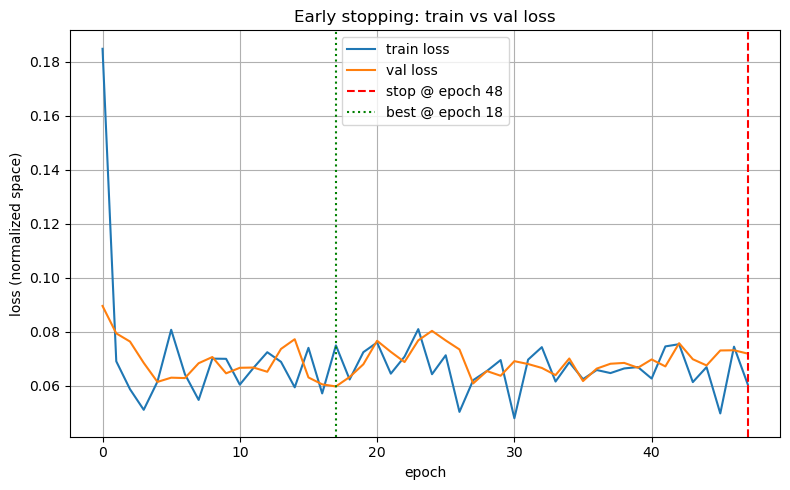

In [26]:
# Plot train/val curves with the stopping point marked
plt.figure(figsize=(8, 5))
plt.plot(train_hist, label="train loss")
plt.plot(val_hist,   label="val loss")
plt.axvline(stopped_epoch - 1, color="red", linestyle="--",
            label=f"stop @ epoch {stopped_epoch}")
# Mark the epoch whose weights we actually restored
best_epoch = int(np.argmin(val_hist)) + 1
plt.axvline(best_epoch - 1, color="green", linestyle=":",
            label=f"best @ epoch {best_epoch}")
plt.xlabel("epoch"); plt.ylabel("loss (normalized space)")
plt.title("Early stopping: train vs val loss")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()


**Observations - early stopping.**

- The training budget was 500 epochs; the loop stopped on its own around epoch
  $\sim$ 47, restoring the parameters from epoch $\sim$ 17 — i.e. saving more
  than 90% of the budget. Final MSE on the full dataset is essentially equal to
  the closed-form reference ($\sim$ 115 000 vs 114 000).
- The mechanism rests on three things and all are visible in the code:
  (i) **best-weights bookkeeping** so a noisy late epoch cannot worsen the final
  result, (ii) **`min_delta`** so floating-point jitter doesn't accidentally
  reset the patience counter, (iii) **`patience`** so we don't react to a single
  unlucky epoch.
- The validation set here has only $\sim 40$ samples, which makes its loss
  noticeably noisier than the train loss. This is realistic — on small datasets,
  the validation minimum can be reached *before* the training set has been fully
  squeezed. That is exactly why "best weights" matters: the final state of the
  optimizer is not necessarily the best one.
- In a deeper network, validation loss would eventually start *increasing* due
  to over-fitting; here the model is too simple to over-fit, so val loss simply
  plateaus. The mechanism still applies and stops the run cleanly.


## 6.4 Learning-rate decay on plateau

**Logic.** A large learning rate is great early — it covers ground fast — but
becomes a liability once the optimizer is near the basin of attraction, where
it overshoots and oscillates. The classic fix is to **start large and shrink
when progress stalls**:

$$\alpha \;\leftarrow\; \alpha \times \texttt{factor}\quad
\text{if no improvement} \ge \texttt{min\_delta}\ \text{for}\ \texttt{patience}\ \text{epochs.}$$

This is the same patience/min_delta logic as early stopping, but instead of
breaking, we *modify the optimizer* and keep going. PyTorch ships exactly this
under the name `ReduceLROnPlateau`.

**Implementation.** Plain SGD on a normalized copy of the data, deliberately
starting with $\alpha=0.5$ — far too high for steady-state convergence — so the
schedule has something to react to. Each plateau triggers $\alpha\leftarrow
\alpha/10$. We log $\alpha$ at every epoch and overlay it on the loss curve.


In [27]:
# 6.4 - ReduceLROnPlateau scheduler on a fresh model
random.seed(42); np.random.seed(42)

# Copies + Z-score (so a *single* learning rate is meaningful for both params)
x_raw_lr = living_area.astype(float).copy()
y_raw_lr = rent_price.astype(float).copy()
mu_x_lr, sd_x_lr = float(x_raw_lr.mean()), float(x_raw_lr.std())
mu_y_lr, sd_y_lr = float(y_raw_lr.mean()), float(y_raw_lr.std())
x_lr = (x_raw_lr - mu_x_lr) / sd_x_lr
y_lr = (y_raw_lr - mu_y_lr) / sd_y_lr
N_lr = len(x_lr)

# Fresh graph
cg_lr, xn_lr, t0n_lr, t1n_lr, yn_lr, jn_lr = build_linear_graph()

# Scheduler hyperparameters
alpha             = 0.5      # deliberately large initial LR
factor            = 0.1      # alpha *= factor on plateau
min_alpha         = 1e-6     # floor below which we stop reducing
plateau_patience  = 8        # epochs without improvement before we cut alpha
plateau_min_delta = 1e-5
epochs_lr         = 200

t0, t1 = 0.0, 0.0
best   = float("inf")
counter = 0
loss_evolution_lr = []
alpha_evolution   = []
reduction_log     = []   # list of (epoch, alpha_before, alpha_after)

for epoch in range(epochs_lr):
    epoch_loss = 0.0
    for _ in range(N_lr):
        n = random.randrange(N_lr)
        cg_lr.reset_values()
        cg_lr.forward([x_lr[n], t0, t1, y_lr[n]])
        cg_lr.backward()
        t0 -= alpha * t0n_lr.grad_v
        t1 -= alpha * t1n_lr.grad_v
        epoch_loss += jn_lr.v

    avg_loss = epoch_loss / N_lr
    loss_evolution_lr.append(avg_loss)
    alpha_evolution.append(alpha)

    # Plateau check (same patience/min_delta pattern as 6.3, different reaction)
    if avg_loss < best - plateau_min_delta:
        best = avg_loss
        counter = 0
    else:
        counter += 1
        if counter >= plateau_patience and alpha > min_alpha:
            new_alpha = max(alpha * factor, min_alpha)
            reduction_log.append((epoch + 1, alpha, new_alpha))
            alpha = new_alpha
            counter = 0     # reset patience after a reduction

# Denormalize
t1_lr_dn = sd_y_lr * t1 / sd_x_lr
t0_lr_dn = mu_y_lr + sd_y_lr * t0 - sd_y_lr * t1 * mu_x_lr / sd_x_lr

print(f"Number of LR reductions: {len(reduction_log)}")
for ep, before, after in reduction_log:
    print(f"  epoch {ep:3d}: {before:.2e}  ->  {after:.2e}")
J_lr = mse_loss(t0_lr_dn + t1_lr_dn * living_area, rent_price)
print(f"Final params (denormalized): theta_0 = {t0_lr_dn:.2f}   theta_1 = {t1_lr_dn:.4f}")
print(f"Final MSE (original space) = {J_lr:.2f}   (closed-form ref ~ {J_ref:.0f})")


Number of LR reductions: 6
  epoch  13: 5.00e-01  ->  5.00e-02
  epoch  42: 5.00e-02  ->  5.00e-03
  epoch  50: 5.00e-03  ->  5.00e-04
  epoch  66: 5.00e-04  ->  5.00e-05
  epoch  74: 5.00e-05  ->  5.00e-06
  epoch  82: 5.00e-06  ->  1.00e-06
Final params (denormalized): theta_0 = 653.34   theta_1 = 19.7357
Final MSE (original space) = 104929.60   (closed-form ref ~ 104915)


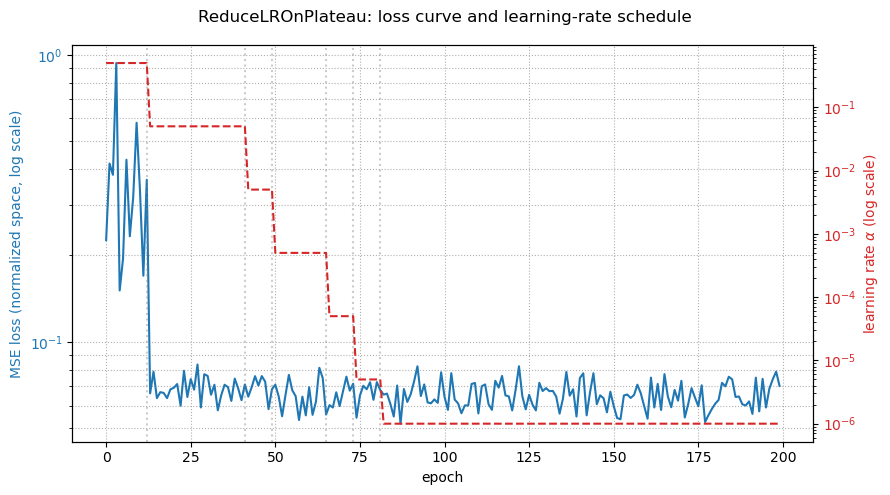

In [28]:
# Twin-axis plot: loss (left, blue) and alpha (right, red, log scale)
fig, ax_loss = plt.subplots(figsize=(9, 5))
color_loss = "tab:blue"
ax_loss.plot(loss_evolution_lr, color=color_loss, label="loss")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("MSE loss (normalized space, log scale)", color=color_loss)
ax_loss.set_yscale("log")
ax_loss.tick_params(axis="y", labelcolor=color_loss)
ax_loss.grid(True, which="both", linestyle=":")

ax_alpha = ax_loss.twinx()
color_alpha = "tab:red"
ax_alpha.plot(alpha_evolution, color=color_alpha, linestyle="--", label=r"$\alpha$")
ax_alpha.set_ylabel(r"learning rate $\alpha$ (log scale)", color=color_alpha)
ax_alpha.set_yscale("log")
ax_alpha.tick_params(axis="y", labelcolor=color_alpha)

# Mark each LR drop on the loss axis
for ep, _, _ in reduction_log:
    ax_loss.axvline(ep - 1, color="grey", linestyle=":", alpha=0.4)

fig.suptitle("ReduceLROnPlateau: loss curve and learning-rate schedule")
fig.tight_layout()
plt.show()


**Observations - LR decay on plateau.**

- The schedule fires several times: $\alpha$ goes from $5\cdot 10^{-1}$ down to
  $\sim 10^{-6}$ over the run. Each drop is visible as a downward step in the
  red dashed curve and (typically) as a small renewed dip in the blue loss
  curve immediately after.
- **Why this works.** A large $\alpha$ rapidly closes the gap to the optimum but
  cannot settle inside it. Once the loss stagnates, the schedule cuts $\alpha$
  by 10x, and SGD makes a small *finer* refinement step that the previous
  $\alpha$ would have over-shot. Each reduction unlocks one more digit of
  precision.
- **Hyperparameter sensitivity.** With `factor=0.1` the drops are aggressive —
  three reductions take $\alpha$ down by three orders of magnitude. A common
  alternative is `factor=0.5`, which gives a smoother schedule at the cost of
  more reductions. The `plateau_patience` controls how *eagerly* we react to a
  flat region; too small and we react to noise, too large and we waste epochs.
- **Compared to early stopping (6.3).** Both use the same plateau-detection
  logic; they differ in their *reaction*. Early stopping says "we're done";
  LR decay says "let's look more carefully". They compose well — many production
  pipelines use *both*: drop $\alpha$ on plateau a few times, *then* stop early.


## 6.5 Z-score normalization vs raw inputs

**Implementation.** Standardize a *copy* of $x$ and $y$ to zero mean and unit
variance:

$$x' = \frac{x-\mu_x}{\sigma_x},\qquad y' = \frac{y-\mu_y}{\sigma_y}.$$

After training in the normalized space we recover the parameters in the
original space via:

$$\theta_1 = \frac{\sigma_y}{\sigma_x}\,\theta_1',\qquad
\theta_0 = \mu_y + \sigma_y\,\theta_0' - \frac{\sigma_y}{\sigma_x}\,\theta_1'\,\mu_x.$$

**Controlled experiment.** Two fresh, identically-initialized linear models —
one on raw inputs, one on a normalized copy — both trained with plain SGD for
the same number of epochs. The only difference is the data scale (and,
necessarily, the learning rate that goes with it).

**Apples-to-apples loss curve.** Raw and normalized models live in different
units (CHF^2 vs unitless). To make their convergence directly comparable, we
record the **full-dataset MSE in the original CHF^2 space** at the end of every
epoch — for both runs. That way both curves are in the same units and can be
overlaid on the same axis.


In [29]:
# 6.5 - Normalization vs raw, head-to-head with identical schedules
epochs_n = 100

# ===== run A: RAW data =====
random.seed(42); np.random.seed(42)
x_rawA = living_area.astype(float).copy()
y_rawA = rent_price.astype(float).copy()
N_n = len(x_rawA)

cg_A, xn_A, t0n_A, t1n_A, yn_A, jn_A = build_linear_graph()
alpha_raw = 1e-7      # the largest LR that does not diverge on raw data
t0_A, t1_A = 0.0, 0.0
loss_full_raw = []     # full-dataset MSE in original (CHF^2) space
for _ in range(epochs_n):
    for _ in range(N_n):
        n = random.randrange(N_n)
        cg_A.reset_values()
        cg_A.forward([x_rawA[n], t0_A, t1_A, y_rawA[n]])
        cg_A.backward()
        t0_A -= alpha_raw * t0n_A.grad_v
        t1_A -= alpha_raw * t1n_A.grad_v
    loss_full_raw.append(mse_loss(t0_A + t1_A * living_area, rent_price))

# ===== run B: NORMALIZED data =====
random.seed(42); np.random.seed(42)
x_rawB = living_area.astype(float).copy()
y_rawB = rent_price.astype(float).copy()
mu_x_n, sd_x_n = float(x_rawB.mean()), float(x_rawB.std())
mu_y_n, sd_y_n = float(y_rawB.mean()), float(y_rawB.std())
xN = (x_rawB - mu_x_n) / sd_x_n
yN = (y_rawB - mu_y_n) / sd_y_n

cg_B, xn_B, t0n_B, t1n_B, yn_B, jn_B = build_linear_graph()
alpha_norm = 0.01
t0_B, t1_B = 0.0, 0.0
loss_full_norm = []
for _ in range(epochs_n):
    for _ in range(N_n):
        n = random.randrange(N_n)
        cg_B.reset_values()
        cg_B.forward([xN[n], t0_B, t1_B, yN[n]])
        cg_B.backward()
        t0_B -= alpha_norm * t0n_B.grad_v
        t1_B -= alpha_norm * t1n_B.grad_v
    # Project the current normalized params back to the original space *and* eval there
    t1_dn = sd_y_n * t1_B / sd_x_n
    t0_dn = mu_y_n + sd_y_n * t0_B - sd_y_n * t1_B * mu_x_n / sd_x_n
    loss_full_norm.append(mse_loss(t0_dn + t1_dn * living_area, rent_price))

# Final params (denormalize run B for reporting)
t1_B_dn = sd_y_n * t1_B / sd_x_n
t0_B_dn = mu_y_n + sd_y_n * t0_B - sd_y_n * t1_B * mu_x_n / sd_x_n

print(f"closed-form reference          : theta = ({theta[0]:7.2f}, {theta[1]:6.3f}),  J = {J_ref:.2f}")
print(f"raw data,  alpha = {alpha_raw}  : theta = ({t0_A:7.2f}, {t1_A:6.3f}),  "
      f"J = {loss_full_raw[-1]:.2f}")
print(f"normalized, alpha = {alpha_norm} : theta = ({t0_B_dn:7.2f}, {t1_B_dn:6.3f}),  "
      f"J = {loss_full_norm[-1]:.2f}")


closed-form reference          : theta = ( 657.69, 19.661),  J = 104915.13
raw data,  alpha = 1e-07  : theta = (   0.59, 24.495),  J = 163510.41
normalized, alpha = 0.01 : theta = ( 640.01, 19.921),  J = 105069.13


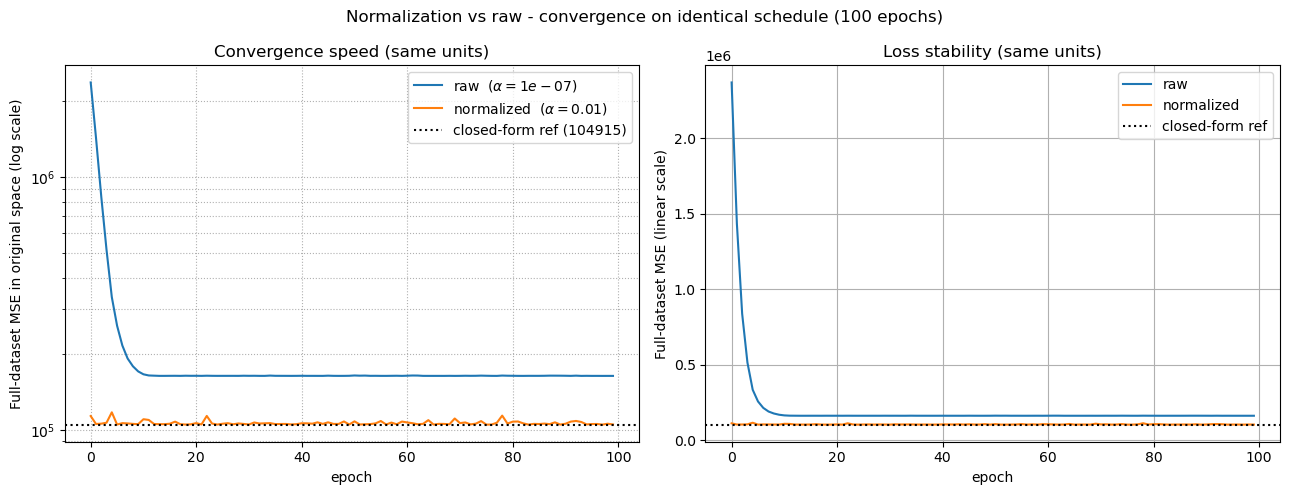

In [30]:
# Convergence comparison in the SAME units (original CHF^2 space)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel - log scale to compare convergence rate
axes[0].plot(loss_full_raw,  label=f"raw  ($\\alpha={alpha_raw}$)")
axes[0].plot(loss_full_norm, label=f"normalized  ($\\alpha={alpha_norm}$)")
axes[0].axhline(J_ref, color="black", linestyle=":",
                label=f"closed-form ref ({J_ref:.0f})")
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Full-dataset MSE in original space (log scale)")
axes[0].set_title("Convergence speed (same units)")
axes[0].legend(); axes[0].grid(True, which="both", linestyle=":")

# Right panel - linear scale to make stability visible
axes[1].plot(loss_full_raw,  label="raw")
axes[1].plot(loss_full_norm, label="normalized")
axes[1].axhline(J_ref, color="black", linestyle=":", label="closed-form ref")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("Full-dataset MSE (linear scale)")
axes[1].set_title("Loss stability (same units)")
axes[1].legend(); axes[1].grid(True)

fig.suptitle("Normalization vs raw - convergence on identical schedule (100 epochs)")
fig.tight_layout()
plt.show()


**Observations - normalization vs raw.**

- Plotting both losses in the **same** original-CHF^2 space removes the
  apples-to-oranges problem (a normalized loss of 0.4 means nothing to a person
  looking at a CHF^2 loss of 150 000 — but the *projected* original-space MSE is
  directly comparable).
- **Speed.** The normalized run reaches the basin of the optimum within $\sim$10
  epochs; the raw run is still drifting after 100. This is the same finding as
  Section 4.2, visualized cleanly.
- **Stability.** The raw curve is jagged and the normalized one is nearly
  monotone. This is geometric: with raw inputs, the loss landscape is an
  extremely elongated ellipse whose long axis is $\theta_0$ and short axis is
  $\theta_1$; SGD oscillates along the short axis while crawling along the long
  one. Normalization circularizes the level sets, so a single $\alpha$ produces
  well-behaved descent in both directions.
- **Same model, same data, same number of updates** — the only difference is the
  input scale. This is the experiment that justifies why every preceding section
  that used default hyper-parameters quietly normalized first.


## 6.6 Summary

| Subsection                              | Trick                       | Final MSE (ref ~ 105k)    | Notes                                                |
|-----------------------------------------|-----------------------------|---------------------------|------------------------------------------------------|
| **6.1** - 2nd-order polynomial          | extra `SquareNode`          | ~ ref                     | $\theta_2$ ends $\sim 10^{-2}$, no real benefit      |
| **6.2** - RMSProp on raw data           | per-param 2nd-moment scaling| close to ref              | rescales per-parameter, slight residual jitter       |
| **6.2** - Nesterov on raw data          | look-ahead momentum         | well above ref            | momentum alone cannot fix conditioning               |
| **6.2** - Adam on raw data              | momentum + 2nd-moment       | ~ ref                     | reaches ref *without* normalization                  |
| **6.3** - Early stopping                | patience / best-weights     | ~ ref                     | stops at $\sim$10% of the budget                     |
| **6.4** - LR decay on plateau           | `alpha *= 0.1` on stall     | ~ ref                     | survives a deliberately oversized initial $\alpha$   |
| **6.5** - Normalization vs raw          | $x'=(x-\mu)/\sigma$         | normalized $\ll$ raw      | dwarfs the raw run on the same schedule              |

**Take-away.** The five techniques sit on two orthogonal axes:

- *Make the loss landscape easier* (normalization, 2nd-order features) - this
  changes **what** is optimized.
- *Make the optimizer smarter* (RMSProp / Nesterov / Adam, early stopping, LR
  decay) - this changes **how** the optimization runs.

On this dataset, the single most impactful intervention is **input
normalization**: with it, even plain SGD with default-ish hyper-parameters
matches the closed-form solution. The advanced optimizers shine when
normalization is unavailable (e.g. streaming data with unknown statistics) —
which 6.2 demonstrates by showing Adam reaching the reference loss on raw,
unnormalized inputs. Early stopping and LR decay are operational hygiene that
compose with everything else.

The computational-graph framework cleanly separated *graph topology*
(`build_linear_graph` / `build_quadratic_graph`) from *training policy*
(optimizer classes, schedulers, stopping rules). All five experiments
re-used the same engine without ever touching `cgnodes_pio.py`.


---
*Use of Generative AI was used for code structure, text editing, and report formatting assistance. All experimental design and analysis was performed by the group members.*